In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

# Pipeline
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import MinMaxScaler


# Métricas de evaluación
from sklearn.metrics import accuracy_score


# Para guardar el modelo
import pickle

In [3]:
df = pd.read_csv('./data/titanic_procesado.csv')

In [6]:
from sklearn.preprocessing import LabelEncoder

# Datos categóricos de ejemplo
animales = ['gato', 'perro', 'pez', 'gato', 'perro']

# Crear una instancia de LabelEncoder
le = LabelEncoder()

# Ajustar y transformar los datos
animales_codificados = le.fit_transform(animales)

# Mostrar los datos codificados
print(animales_codificados)

# Si deseas ver cómo se mapean las etiquetas originales
print(list(le.classes_))

[0 1 2 0 1]
[np.str_('gato'), np.str_('perro'), np.str_('pez')]


In [7]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

# Fit and transform on training data
df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

In [8]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
451,0,3,1,28.0,1,0,19.9667,2
861,0,2,1,21.0,1,0,11.5000,2
67,0,3,1,19.0,0,0,8.1583,2
596,1,2,0,28.0,0,0,33.0000,2
513,1,1,0,54.0,1,0,59.4000,0


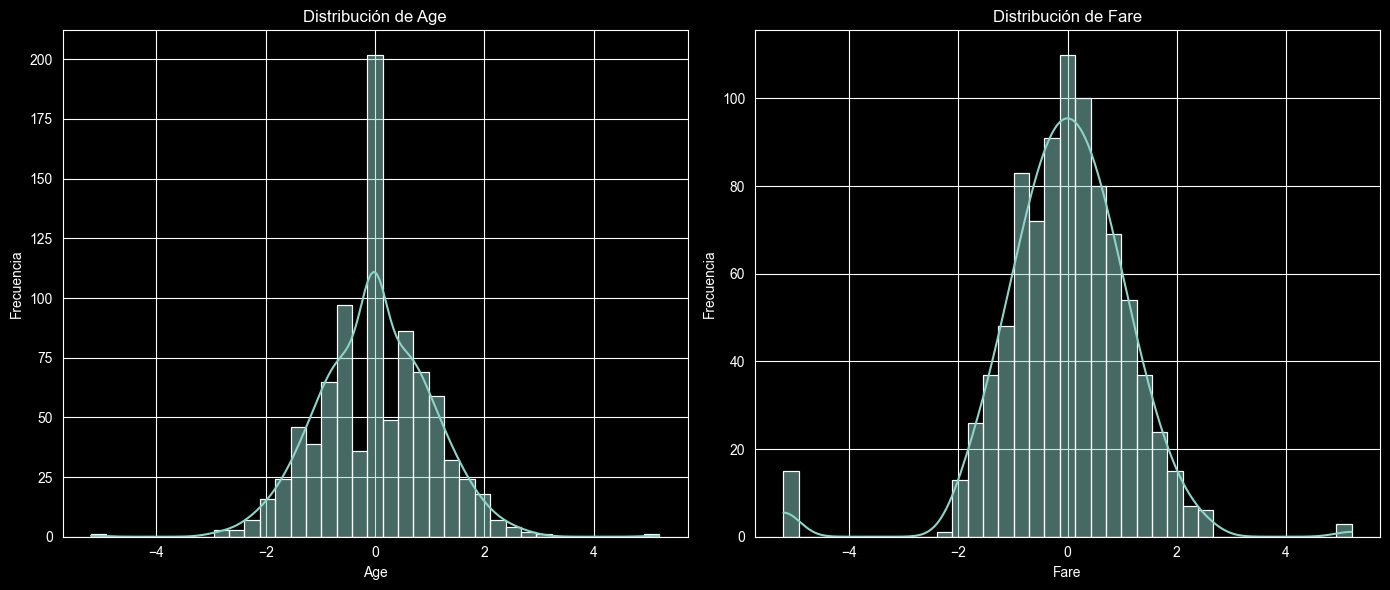

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

# Mostrar las gráficas
plt.tight_layout()
plt.show()

In [16]:
qun_tra_age = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

In [20]:
mms_pclass= MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

# Ejecutar transformaciones
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

In [21]:
df.to_csv('./data/titanic_procesado.csv', index=False)

In [22]:
df = pd.read_csv('./data/titanic_procesado.csv')

In [23]:
X = df.drop(['Survived'], axis=1)
y = df['Survived']

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,1.0,0.433152,0.125,0.0,0.368146,1.0
1,0.0,0.0,0.579431,0.125,0.0,0.615097,0.0
2,1.0,0.0,0.462346,0.000,0.0,0.438286,1.0
3,0.0,0.0,0.563806,0.125,0.0,0.595112,1.0
4,1.0,1.0,0.563806,0.000,0.0,0.448347,1.0


In [24]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train = X_train.values  # Convertir a NumPy array
y_train = y_train.values  # Convertir a NumPy array
X_test = X_test.values    # Convertir a NumPy array
y_test = y_test.values    # Convertir a NumPy array

In [26]:
modelos = {
    'Logistic Regression': {
        'model': LogisticRegression(),
        'params': {
            'model__C': [0.1],
            'model__max_iter': [1000]
        }
    },
    'Support Vector Classifier': {
        'model': SVC(),
        'params': {
            'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
            'model__C': [0.1, 1, 10]
        }
    },
    'Decision Tree Classifier': {
        'model': DecisionTreeClassifier(),
        'params': {
            'model__splitter': ['best', 'random'],
            'model__max_depth': [None, 1, 2, 3, 4]
        }
    },
    'Random Forest Classifier': {
        'model': RandomForestClassifier(),
        'params': {
            'model__n_estimators': [10, 100],
            'model__max_depth': [None, 1, 2, 3, 4],
            'model__max_features': ['auto', 'sqrt', 'log2']
        }
    },
    'Gradient Boosting Classifier': {
        'model': GradientBoostingClassifier(),
        'params': {
            'model__n_estimators': [10, 100],
            'model__max_depth': [None, 1, 2, 3, 4]
        }
    },
    'AdaBoost Classifier': {
        'model': AdaBoostClassifier(),
        'params': {
            'model__n_estimators': [10, 100]
        }
    },
    'K-Nearest Neighbors Classifier': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7]
        }
    },
    'XGBoost Classifier': {
        'model': XGBClassifier(),
        'params': {
            'model__n_estimators': [10, 100],
            'model__max_depth': [None, 1, 2, 3]
        }
    },
    'LGBM Classifier': {
        'model': LGBMClassifier(),
        'params': {
            'model__n_estimators': [10, 100],
            'model__max_depth': [None, 1, 2, 3],
            'model__learning_rate': [0.1, 0.2, 0.3],
            'model__verbose': [-1]
        }
    },
    'GaussianNB': {
        'model': GaussianNB(),
        'params': {}
    },
    'Naive Bayes Classifier': {
        'model': BernoulliNB(),
        'params': {
            'model__alpha': [0.1, 1.0, 10.0]
        }
    }
}

In [27]:
# Definir los modelos y sus respectivos hiperparámetros para GridSearch
modelos = {
    'Regresión Logística': {
        'modelo': LogisticRegression(),
        'parametros': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'max_iter': [100, 500, 1000]
        }
    },
    'Clasificador de Vectores de Soporte': {
        'modelo': SVC(),
        'parametros': {
            'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
            'C': [0.1, 1, 10]
        }
    },
    'Clasificador de Árbol de Decisión': {
        'modelo': DecisionTreeClassifier(),
        'parametros': {
            'splitter': ['best', 'random'],
            'max_depth': [None, 1, 2, 3, 4]
        }
    },
    'Clasificador de Bosques Aleatorios': {
        'modelo': RandomForestClassifier(),
        'parametros': {
            'n_estimators': [10, 100],
            'max_depth': [None, 1, 2, 3, 4],
            'max_features': ['sqrt', 'log2', None]
        }
    },
    'Clasificador de Gradient Boosting': {
        'modelo': GradientBoostingClassifier(),
        'parametros': {
            'n_estimators': [10, 100],
            'max_depth': [None, 1, 2, 3, 4]
        }
    },
    'Clasificador AdaBoost': {
        'modelo': AdaBoostClassifier(),
        'parametros': {
            'n_estimators': [10, 100]
        }
    },
    'Clasificador K-Nearest Neighbors': {
        'modelo': KNeighborsClassifier(),
        'parametros': {
            'n_neighbors': [3, 5, 7]
        }
    },
    'Clasificador XGBoost': {
        'modelo': XGBClassifier(),
        'parametros': {
            'n_estimators': [10, 100],
            'max_depth': [None, 1, 2, 3]
        }
    },
    'Clasificador LGBM': {
        'modelo': LGBMClassifier(),
        'parametros': {
            'n_estimators': [10, 100],
            'max_depth': [None, 1, 2, 3],
            'learning_rate': [0.1, 0.2, 0.3],
            'verbose': [-1]
        }
    },
    'GaussianNB': {
        'modelo': GaussianNB(),
        'parametros': {}
    },
    'Clasificador Naive Bayes': {
        'modelo': BernoulliNB(),
        'parametros': {
            'alpha': [0.1, 1.0, 10.0]
        }
    }
}

# Inicializar variables para almacenar los puntajes de los modelos y el mejor estimador
puntajes_modelos = []
mejor_precision = 0
mejor_estimador = None
mejor_modelo = None
estimadores = {}

# Iterar sobre cada modelo y sus hiperparámetros
for nombre, info_modelo in modelos.items():
    # Inicializar GridSearchCV con el modelo y los hiperparámetros
    grid_search = GridSearchCV(
        estimator=info_modelo['modelo'],
        param_grid=info_modelo['parametros'],
        cv=5,
        scoring='accuracy',
        verbose=0,
        n_jobs=-1,
    )

    # Ajustar GridSearchCV con los datos de entrenamiento
    grid_search.fit(X_train, y_train)

    # Hacer predicciones con el modelo ajustado
    y_pred = grid_search.predict(X_test)

    # Calcular la precisión de las predicciones
    precision = accuracy_score(y_test, y_pred)

    # Almacenar los resultados del modelo
    puntajes_modelos.append({
        'Modelo': nombre,
        'Precisión': precision
    })

    estimadores[nombre] = grid_search.best_estimator_

    # Actualizar el mejor modelo si la precisión actual es mayor que la mejor precisión encontrada
    if precision > mejor_precision:
        mejor_modelo = nombre
        mejor_precision = precision
        mejor_estimador = grid_search.best_estimator_

# Convertir los resultados a un DataFrame para una mejor visualización
metricas = pd.DataFrame(puntajes_modelos).sort_values('Precisión', ascending=False)

# Imprimir el rendimiento de los modelos de clasificación
print("Rendimiento de los modelos de clasificación")
print(metricas.round(2))

# Imprimir el mejor modelo y su precisión
print('---------------------------------------------------')
print("MEJOR MODELO DE CLASIFICACIÓN")
print(f"Modelo: {mejor_modelo}")
print(f"Precisión: {mejor_precision:.2f}")

C:\Users\ipadp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Rendimiento de los modelos de clasificación
                                 Modelo  Precisión
4     Clasificador de Gradient Boosting       0.84
6      Clasificador K-Nearest Neighbors       0.83
3    Clasificador de Bosques Aleatorios       0.82
7                  Clasificador XGBoost       0.82
8                     Clasificador LGBM       0.81
1   Clasificador de Vectores de Soporte       0.80
2     Clasificador de Árbol de Decisión       0.80
0                   Regresión Logística       0.79
5                 Clasificador AdaBoost       0.79
10             Clasificador Naive Bayes       0.79
9                            GaussianNB       0.76
---------------------------------------------------
MEJOR MODELO DE CLASIFICACIÓN
Modelo: Clasificador de Gradient Boosting
Precisión: 0.84


C:\Users\ipadp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
# Esto ya lo tenemos importado. Lo ponemos nuevamente nada más de referencia
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# Creamos el modelo de regresión logística
model = LogisticRegression()

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

# Realizamos predicciones con el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluamos el modelo usando precisión
accuracy = accuracy_score(y_test, y_pred)

print(f"Precisión del modelo: {accuracy:.2f}")

Precisión del modelo: 0.80


In [29]:
model = LogisticRegression(
    C=0.5,                  # Valor de regularización
    penalty='l2',            # Tipo de penalización (l2 es la regularización Ridge)
    solver='lbfgs',         # Algoritmo de optimización
    max_iter=200,           # Número máximo de iteraciones
    class_weight='balanced' # Ajustar pesos de las clases
)

# Entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)

print(f"Precisión del modelo: {accuracy:.2f}")

Precisión del modelo: 0.78


C:\Users\ipadp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [32]:
# Inicializar variables para almacenar los puntajes de los modelos y el mejor estimador
puntajes_modelos = []
mejor_precision = 0
mejor_estimador = None
mejor_modelo = None
estimadores = {}

In [34]:
# Iterar sobre cada modelo y sus hiperparámetros
for nombre, info_modelo in modelos.items():
    grid_search = GridSearchCV(
    estimator=info_modelo['modelo'],
    param_grid=info_modelo['parametros'],
    cv=5,
    scoring='accuracy',
    verbose=0,
    n_jobs=-1,
)

In [35]:
# Ajustar GridSearchCV con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Hacer predicciones con el modelo ajustado
y_pred = grid_search.predict(X_test)

# Calcular la precisión de las predicciones
precision = accuracy_score(y_test, y_pred)

# Almacenar los resultados del modelo
puntajes_modelos.append({
    'Modelo': nombre,
    'Precisión': precision
})

estimadores[nombre] = grid_search.best_estimator_

In [36]:
# Actualizar el mejor modelo si la precisión actual es mayor que la mejor precisión encontrada
if precision > mejor_precision:
    mejor_modelo = nombre
    mejor_precision = precision
    mejor_estimador = grid_search.best_estimator_

In [37]:
# Convertir los resultados a un DataFrame para una mejor visualización
metricas = pd.DataFrame(puntajes_modelos).sort_values('Precisión', ascending=False)

# Imprimir el rendimiento de los modelos de clasificación
print("Rendimiento de los modelos de clasificación")
print(metricas.round(2))

# Imprimir el mejor modelo y su precisión
print('---------------------------------------------------')
print("MEJOR MODELO DE CLASIFICACIÓN")
print(f"Modelo: {mejor_modelo}")
print(f"Precisión: {mejor_precision:.2f}")

Rendimiento de los modelos de clasificación
                     Modelo  Precisión
0  Clasificador Naive Bayes       0.79
---------------------------------------------------
MEJOR MODELO DE CLASIFICACIÓN
Modelo: Clasificador Naive Bayes
Precisión: 0.79


In [38]:
# Convertir los resultados a un DataFrame para una mejor visualización
metricas = pd.DataFrame(puntajes_modelos).sort_values('Precisión', ascending=False)

# Imprimir el rendimiento de los modelos de clasificación
print("Rendimiento de los modelos de clasificación")
print(metricas.round(2))

# Imprimir el mejor modelo y su precisión
print('---------------------------------------------------')
print("MEJOR MODELO DE CLASIFICACIÓN")
print(f"Modelo: {mejor_modelo}")
print(f"Precisión: {mejor_precision:.2f}")

Rendimiento de los modelos de clasificación
                     Modelo  Precisión
0  Clasificador Naive Bayes       0.79
---------------------------------------------------
MEJOR MODELO DE CLASIFICACIÓN
Modelo: Clasificador Naive Bayes
Precisión: 0.79


In [40]:
X_train[0]

array([0.        , 1.        , 0.61581699, 0.        , 0.        ,
       0.55559921, 1.        ])

In [41]:
y_train[0]

np.int64(0)

In [42]:
nuevos_datos = np.array([0,1,0.6159084,0,0,0.55547282,1]).reshape(1,-1)

In [43]:
mejor_estimador.predict(nuevos_datos)

array([0])

In [45]:
import pickle

In [46]:
with open('modelo.pkl', 'wb') as archivo_estimador:
    pickle.dump(mejor_estimador, archivo_estimador)